load the libaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan

load the umap embeddings

In [4]:
# =========================================================
# LOAD UMAP EMBEDDINGS
# =========================================================

umap_embeddings = np.load(
    "../embeddings/umap_embeddings.npy"
)

print("UMAP shape:")
print(umap_embeddings.shape)

UMAP shape:
(47770, 2)


create and load the hdbscan model

In [5]:
# =========================================================
# CREATE HDBSCAN MODEL
# =========================================================

clusterer = hdbscan.HDBSCAN(

    min_cluster_size=500,
    min_samples=170
)


fit the model

In [6]:
# =========================================================
# FIT + PREDICT CLUSTERS
# =========================================================

cluster_labels = clusterer.fit_predict(
    umap_embeddings
)


In [7]:
# =========================================================
# NUMBER OF CLUSTERS
# =========================================================

num_clusters = len(
    set(cluster_labels)
) - (1 if -1 in cluster_labels else 0)

print(f"\nNumber of clusters: {num_clusters}")

# =========================================================
# NUMBER OF NOISE POINTS
# =========================================================

noise_points = np.sum(cluster_labels == -1)

print(f"Noise points: {noise_points}")


Number of clusters: 5
Noise points: 2224


show clusters

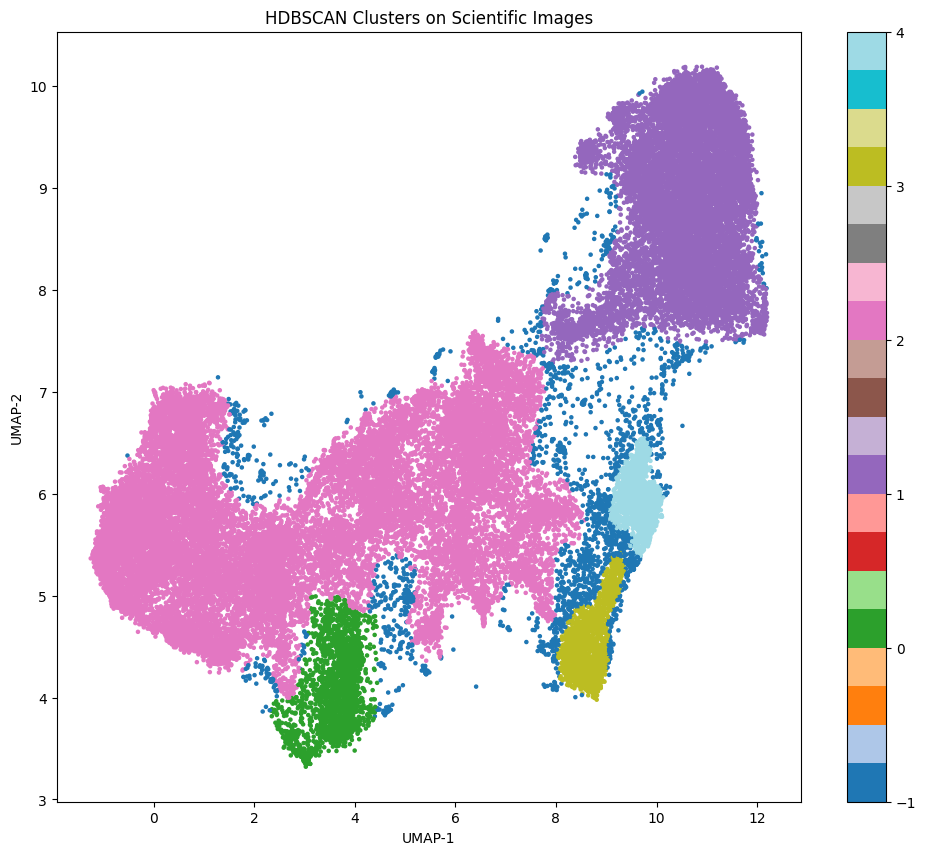

In [9]:
# =========================================================
# PLOT CLUSTERS
# =========================================================

plt.figure(figsize=(12,10))

scatter = plt.scatter(

    umap_embeddings[:,0],

    umap_embeddings[:,1],

    c=cluster_labels,

    cmap='tab20',

    s=5
)

plt.title(
    "HDBSCAN Clusters on Scientific Images"
)

plt.xlabel("UMAP-1")

plt.ylabel("UMAP-2")

plt.colorbar(scatter)

plt.show()

saving the labels

In [10]:
# =========================================================
# SAVE LABELS
# =========================================================

np.save(
    "../embeddings/hdbscan_labels.npy",
    cluster_labels
)

print("\nCluster labels saved!")


Cluster labels saved!
